In [1]:
import matplotlib.pyplot as plt  
import numpy as np  

import colors
import handcalcs.render 

def graf(v=5, s=5):
    '''
        Funkcija pripravi graf in nastavi koordinatne osi 
    '''
    fig, ax = plt.subplots(figsize=(s,v))
    ax.set_prop_cycle(color=colors.Texas)
    ax.set_xlabel('x', loc='right')
    ax.set_ylabel('y', loc='top')
    ax.spines[['left', 'bottom']].set_position('zero')
    ax.spines[['top', 'right']].set_visible(False);
    ax.axis('equal') 
    return ax

#np.set_printoptions(legacy='1.25')

# Vaja 2 - risanje grafov funkcije

Numerični pristop k risanju grafa funkcije zahteva, da ustvarimo zadosti veliko število vrednosti neodvisne spremenljivke, ki pripadajo definicijskemu območju funkcije in nato za vsako od teh vrednosti izračunamo pripadajočo funkcijsko vrednost.

Z uporabo NumPy zelo preprosto tabeliramo poljuben nabor vrednosti neodvisne spremenljivke. Za izračun funkcijske vrednosti uporabimo zmožnost `ndarray`, da operacije izvede nad vsemi elementi polja (ang. _broadcasting_). Tako z vsemi vrednostmi računamo enako, kot bi računali z eno samo vrednostjo. 

Zaradi preglednosti lahko funkcijo definiramo kot Python uporabniško definirano funkcijo.

OPOMBA: \
Nekateri primeri funkcij so povzeti iz zbirke rešenih nalog za študente Fakultete za gradbeništvo, prometno inženirstvo in arhitekturo, Univerze v Mariboru, kjer najdete dodatne opise in matematične postopke reševanja:

Mencinger, M. (2011). _Zbirka rešenih nalog iz matematične analize in algebre_. Univerza v Mariboru  

### Eksplicitno podane funkcije
Funkcijo lahko podamo v eksplicitni obliki $y = f(x)$. Risanje grafov tako podanih funkcij je nadvse preprosto. Poglejmo si nekaj primerov.

##### Primer:
(1.2 naloga 1, str 12)

Nariši graf funkcije $y=\lvert x+1 \rvert + \lvert x-1 \rvert$

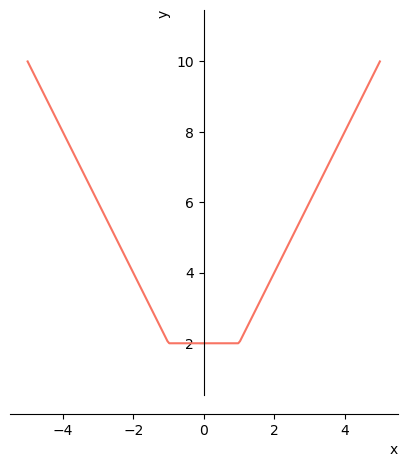

In [2]:
def f(x):
    return np.abs(x+1) + np.abs(x-1)

x = np.linspace(-5, 5, 200)

ax = graf()
ax.plot(x, f(x));

##### Primer:
(1.2 naloga 5, str 12)

Nariši graf funkcije $y=log_3(x-2)$

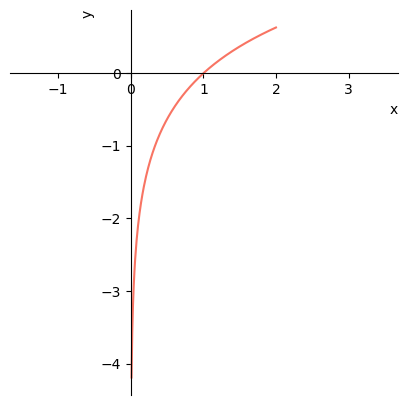

In [3]:
def f(x):
    return np.log(x)/np.log(3)

x = np.linspace(0.01, 2, 200)

ax = graf()
ax.plot(x, f(x));

##### Primer:
(1.2 naloga 5, str 12)

Nariši graf funkcije $y=\frac{1}{2}(e^x-e^{-x})$

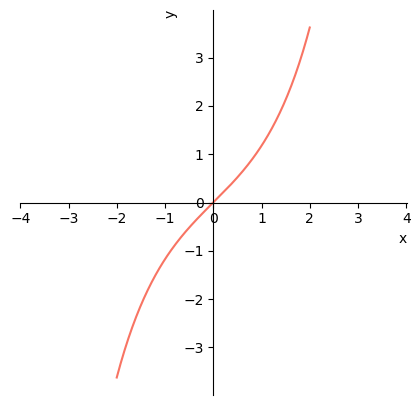

In [4]:
def f(x):
    return (np.exp(x)-np.exp(-x))/2

x = np.linspace(-2, 2, 200)

ax = graf()
ax.plot(x, f(x));


##### Primer:
(1.2 naloga 5, str 12)

Nariši graf funkcije $y=\lvert x^3 \rvert-2$

Graf prikazuje postopno konstrukcijo končne rešitve z uporabo translacije funkcije $x^3$ za -2 v smeri osi $y$ in nato zrcaljenja dela krivulje levo od $y$ osi okoli translirane osi $x$.

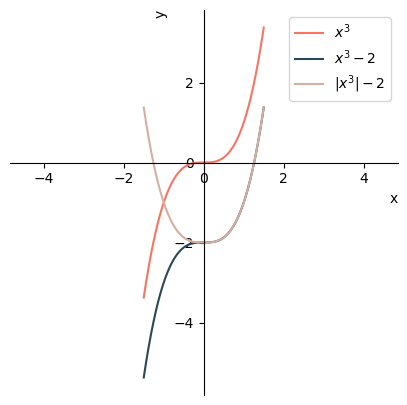

In [5]:
def f(x):
    return np.abs(x**3)-2

def g(x):
    return x**3

x = np.linspace(-1.5, 1.5, 200)
ax = graf()
ax.plot(x, g(x), label='$x^3$')
ax.plot(x, g(x)-2, label='$x^3-2$')
ax.plot(x, f(x), label='$|x^3|-2$')
ax.legend();

### Parametrično podane funkcije
Nekatere krivulje ne moremo preprosto zapisati tako, da z običajno funkcijsko enačbo vrednost $y$ izrazimo  neposredno z $x$. Parametrični zapis včasih omogoča bolj intuitiven zapis funkcijske odvisnosti, tako da obe vrednosti $x$ in $y$ izrazimo s skupnim tretjim parametrom $t$.

##### Primer:
Nariši graf parametrično podane funkcije za vrednosti $-\pi \leq t \leq \pi$
$$ x = 16 \sin{t}^3$$
$$ y = 7 \cos{t} - 5 \cos{t}^2 - 2\cos{t}^3 - \cos{t}^4$$

 \
Nato funkcijo spremeni, da potence v izrazu za $y$ preneseš na vrednost kosinusov. 

$$ y = 7 \cos{t} - 5 \cos^2{t} - 2\cos^3{t} - \cos^4{t}$$

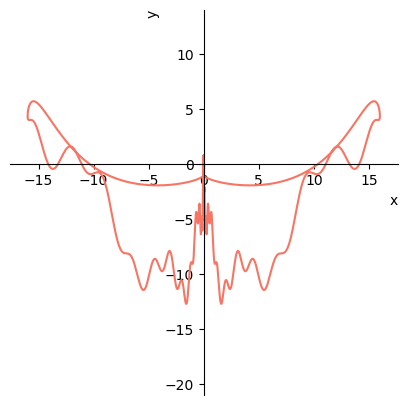

In [6]:
def f1(t):
    x = 16* np.sin(t)**3
    y = 7 * np.cos(t) - 5 * np.cos(t**2) - 2*np.cos(t**3) - np.cos(t**4)
    return x, y

def f2(t):
    x = 16* np.sin(t)**3
    y = 7 * np.cos(t) - 5 * np.cos(t)**2 - 2*np.cos(t)**3 - np.cos(t)**4
    return x, y

t = np.linspace(-np.pi, np.pi, 1000)

ax = graf()

x, y = f1(t)  #poskusi zamenjati f1 v f2
ax.plot(x, y);


##### Primer:
Nariši graf parametrično podane funkcije za vrednosti $-\pi \leq t \leq \pi$
$$x = \cos{t} - \frac{\sin^2{t}}{\sqrt{2}}$$
$$y = \cos{t} \cdot \sin{t}$$

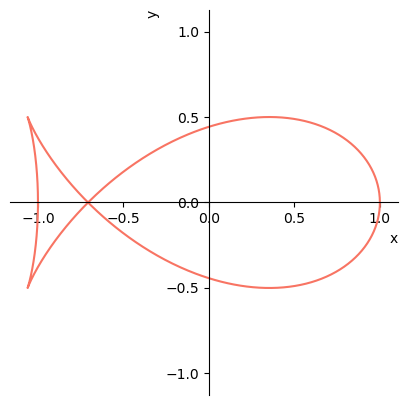

In [8]:
def f(t):
    x = np.cos(t) - np.sin(t)**2/np.sqrt(2)
    y = np.cos(t) * np.sin(t)
    return x, y

t = np.linspace(-np.pi, np.pi, 1000)

ax = graf()

x, y = f(t)  
ax.plot(x, y);


### Polarne koordinate

Za zapis točk v ravnini lahko uporabimo polarni koordinatni sistem. Polarni kooordinatni sistem je ravninski sistem, kjer lokacijo točke opišemo z oddaljenostjo od izhodišča, kar imenujemo __radij__ in __polarnim kotom__, ki ga radij oklepa z desnim delom horizontalne osi. Radij navadno označimo z $r$ in polarni kot s $\varphi$.

Med kartezičnim in polarnim koordinatnim sistemom lahko koordinate pretvarjamo po obrazcih:
$$x = r\cdot \cos{\varphi}$$
$$y = r\cdot \sin{\varphi}$$
in obratno
$$r = \sqrt{x^2+y^2}$$
$$\varphi = \frac{y}{x}$$

Funkcije podane v polarnem koordinatnem sistemu z Matplotlib narišemo tako, da polarne koordinate preslikamo v kartezične in postopamo podobno, kot pri parametrično podanih funkcijah. Matplotlib pa omogoča tudi neposredno uporabo polarnih kooordinat, saj ob ustvarjanju grafa lahko določimo projekcijo, ki jo želimo uporabiti za prikaz. Poglejmo oba primera.

#### Preslikava v kartezični koordinatni sistem

##### Primer
Spiralo v polarnih koordinatah zapišemo z izrazom
$$r = \sqrt{\varphi}$$

Nariši potek funkcije v kartezičnem koordinatnem sistemu.

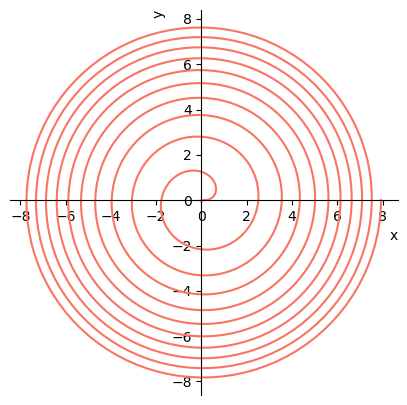

In [9]:
def spirala(phi):
    #radij je funkcija kota
    r = np.sqrt(phi)
    
    #pretvorimo v katrezične koordinate
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return x, y

phi = np.linspace(0, 20*np.pi, 1000)
x, y = spirala(phi)

ax = graf()
ax.plot(x, y);

#### Prikaz z uporabo projekcije _polar_

Pri ustvarjanju grafa s funkcijo `subplots()` projekcijo spremenimo v 'polar'. Za prikaz uporabimo običajne funkcije, kot so `plot()` ali `scatter()`, ki jim posredujemo argumente v polarnih koordinatah.  

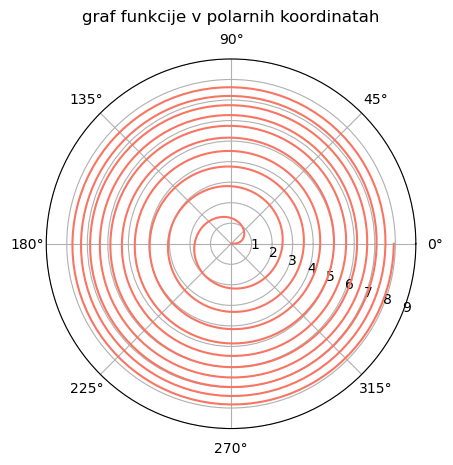

In [11]:
phi = np.linspace(0, 20*np.pi, 1000)
r = np.sqrt(phi)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(phi, r, color='#f87463')
ax.set_rmax(9)
ax.set_rlabel_position(-22.5)  
ax.grid(True)

ax.set_title("graf funkcije v polarnih koordinatah", va='bottom');